# Diabetes Prediction with the 100,000-record Dataset

This notebook preserves the project workflow while adapting it to the new dataset. It covers inspection, justified cleaning, reasonable EDA, leakage-safe preprocessing, the three required models, evaluation, comparison, and persistence.

## 1. Import Libraries

The libraries below support tabular analysis, visualization, preprocessing, the two sklearn models, and the PyTorch neural network.

In [1]:
from pathlib import Path
import random
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

sns.set_theme(style="whitegrid")


## 2. Load Dataset

The CSV is resolved relative to the notebook, making the workflow reproducible when run from the project root or notebook directory.

In [2]:
DATA_PATH = Path("data/raw/diabetes_prediction_dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/diabetes_prediction_dataset.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"Shape: {df.shape}")
df.head()


Dataset path: /home/bhairava/Projects/Diabetes-Prediction/data/raw/diabetes_prediction_dataset.csv
Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Initial Dataset Inspection

The target is `diabetes`. The actual schema is inspected rather than inherited from the previous Pima-style dataset.

In [3]:
TARGET = "diabetes"
assert TARGET in df.columns

print(df.info())
print("\nMissing values:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print("\nUnique values:")
print(df.nunique())
print("\nTarget distribution:")
print(df[TARGET].value_counts())
print((df[TARGET].value_counts(normalize=True) * 100).round(2))


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 3,854


## 4. Data Cleaning

There are no missing values, invalid categorical values, or non-positive measurements in this file. Exact duplicate records are removed because they repeat the same observation and can make evaluation over-optimistic. No other rows are removed without evidence of a data-entry problem.

In [4]:
EXPECTED_CATEGORIES = {
    "gender": {"Female", "Male", "Other"},
    "smoking_history": {"No Info", "current", "ever", "former", "never", "not current"},
}
NUMERIC_COLUMNS = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
BINARY_COLUMNS = ["hypertension", "heart_disease"]

invalid_categories = {
    column: sorted(set(df[column].dropna().unique()) - values)
    for column, values in EXPECTED_CATEGORIES.items()
}
invalid_numeric = {column: int((df[column] <= 0).sum()) for column in NUMERIC_COLUMNS}
invalid_binary = {column: sorted(set(df[column].dropna().unique()) - {0, 1}) for column in BINARY_COLUMNS + [TARGET]}
print("Invalid categories:", invalid_categories)
print("Non-positive numeric values:", invalid_numeric)
print("Invalid binary values:", invalid_binary)

rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before cleaning: {rows_before:,}")
print(f"Duplicate rows removed: {rows_before - len(df):,}")
print(f"Rows after cleaning: {len(df):,}")
assert df.isna().sum().sum() == 0


Invalid categories: {'gender': [], 'smoking_history': []}
Non-positive numeric values: {'age': 0, 'bmi': 0, 'HbA1c_level': 0, 'blood_glucose_level': 0}
Invalid binary values: {'hypertension': [], 'heart_disease': [], 'diabetes': []}
Rows before cleaning: 100,000
Duplicate rows removed: 3,854
Rows after cleaning: 96,146


## 5. Exploratory Data Analysis

The target is strongly imbalanced, with diabetes positive in 8.5% of rows. The plots below use the cleaned data and focus on distributions and relationships that can inform preprocessing and model interpretation.

                       count unique     top   freq        mean        std  \
gender                 96146      3  Female  56161         NaN        NaN   
age                  96146.0    NaN     NaN    NaN   41.794326  22.462948   
hypertension         96146.0    NaN     NaN    NaN    0.077601   0.267544   
heart_disease        96146.0    NaN     NaN    NaN    0.040803   0.197833   
smoking_history        96146      6   never  34398         NaN        NaN   
bmi                  96146.0    NaN     NaN    NaN   27.321461   6.767716   
HbA1c_level          96146.0    NaN     NaN    NaN    5.532609   1.073232   
blood_glucose_level  96146.0    NaN     NaN    NaN  138.218231  40.909771   
diabetes             96146.0    NaN     NaN    NaN     0.08822   0.283616   

                       min    25%    50%    75%    max  
gender                 NaN    NaN    NaN    NaN    NaN  
age                   0.08   24.0   43.0   59.0   80.0  
hypertension           0.0    0.0    0.0    0.0    1.0  
h

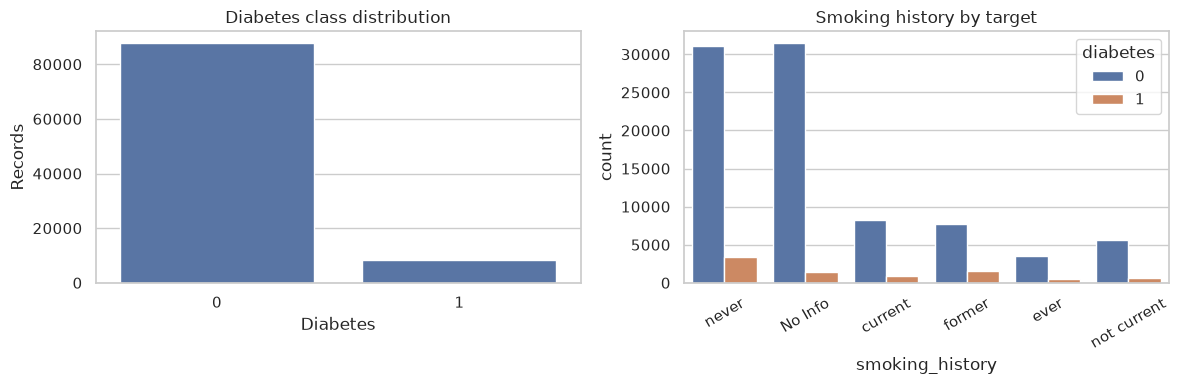

In [5]:
print(df.describe(include="all").transpose())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=TARGET, ax=axes[0])
axes[0].set_title("Diabetes class distribution")
axes[0].set_xlabel("Diabetes")
axes[0].set_ylabel("Records")
sns.countplot(data=df, x="smoking_history", hue=TARGET, ax=axes[1])
axes[1].set_title("Smoking history by target")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


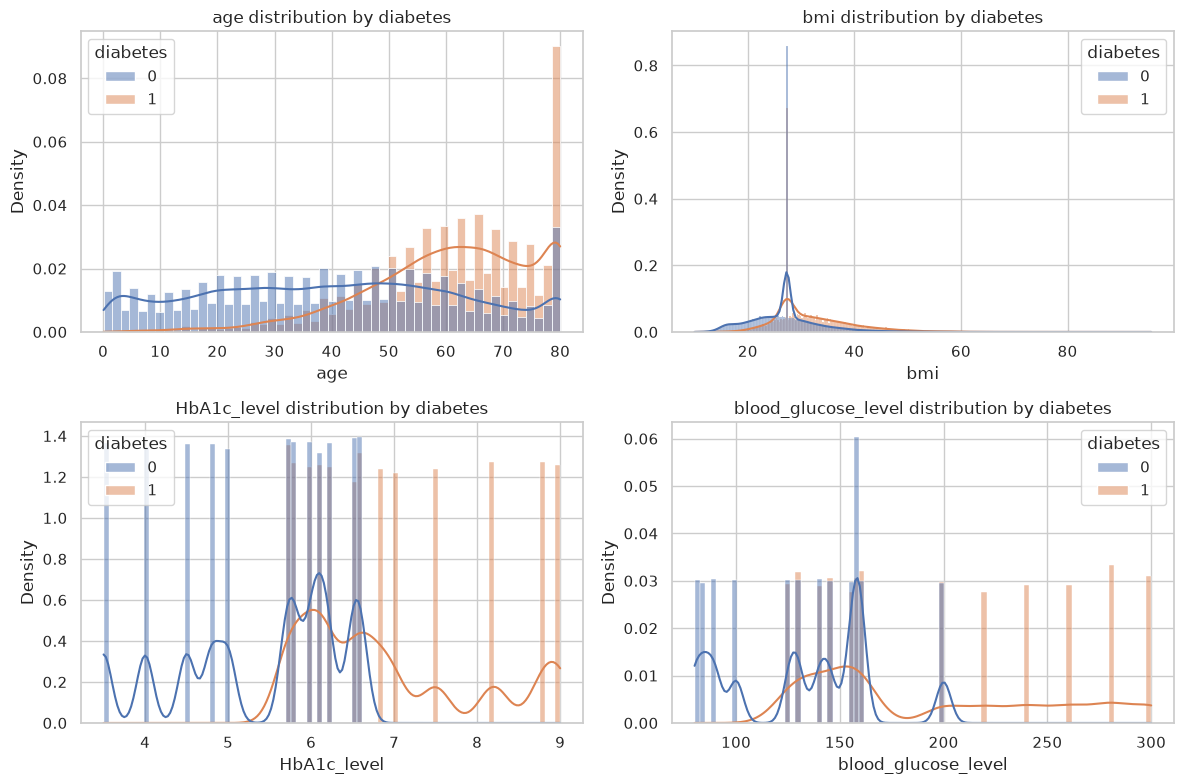

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for column, ax in zip(NUMERIC_COLUMNS, axes.flat):
    sns.histplot(data=df, x=column, hue=TARGET, kde=True, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{column} distribution by diabetes")
plt.tight_layout()
plt.show()


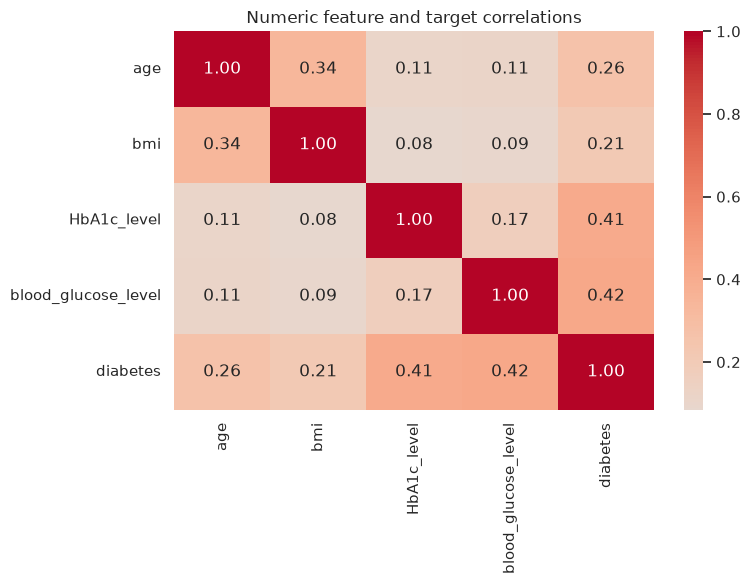

Potential outlier ranges are shown by the descriptive statistics; values are retained because they are within plausible dataset ranges.


In [7]:
eda_numeric = df[NUMERIC_COLUMNS + [TARGET]].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(eda_numeric, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric feature and target correlations")
plt.tight_layout()
plt.show()

print("Potential outlier ranges are shown by the descriptive statistics; values are retained because they are within plausible dataset ranges.")


## 6. Data Preprocessing and Train/Test Split

The split happens before fitting preprocessing to prevent information from the test set leaking into training. Numeric features are standardized for Logistic Regression and PyTorch; categorical features are one-hot encoded. The same fitted transformer is shared by all three models.

In [8]:
X = df.drop(columns=TARGET)
y = df[TARGET].astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_features = NUMERIC_COLUMNS + BINARY_COLUMNS
categorical_features = ["gender", "smoking_history"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
print(X_train_processed.shape, X_test_processed.shape)


(76916, 15) (19230, 15)


## 7. Logistic Regression

This uses sklearn’s established implementation. `max_iter=1000` gives the solver enough iterations for convergence after preprocessing, and `class_weight="balanced"` accounts for the imbalanced target without duplicating samples.

In [9]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logistic_pipeline.fit(X_train, y_train)
logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


## 8. Random Forest

Random Forest captures nonlinear feature interactions. The moderate tree count and constrained depth keep training practical for 80,000 training records, while `n_jobs=-1` uses available CPU cores.

In [10]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=16, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )),
])
random_forest_pipeline.fit(X_train, y_train)
random_forest_pred = random_forest_pipeline.predict(X_test)
random_forest_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]


## 9. PyTorch Neural Network

The network uses two hidden layers with ReLU activations and one logit output. `BCEWithLogitsLoss` combines a numerically stable sigmoid and binary cross-entropy; mini-batches make training practical for this dataset.

/home/bhairava/Projects/Diabetes-Prediction/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce MX350 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.1+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.1 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/bhairava/Projects/Diabetes-Prediction/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:602:

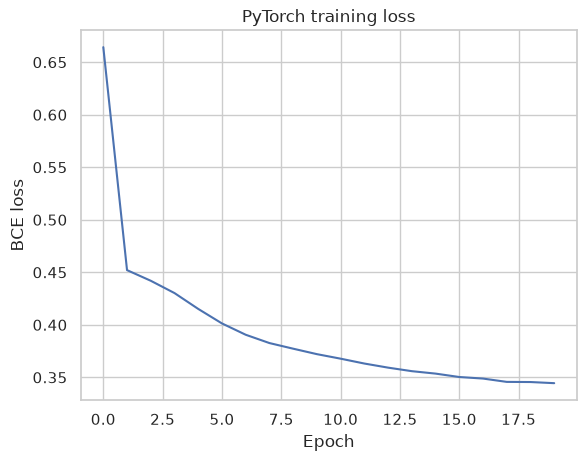

In [11]:
class DiabetesNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, features):
        return self.network(features)

X_train_tensor = torch.tensor(X_train_processed.to_numpy(dtype=np.float32))
y_train_tensor = torch.tensor(y_train.to_numpy(dtype=np.float32)).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_processed.to_numpy(dtype=np.float32))
y_test_tensor = torch.tensor(y_test.to_numpy(dtype=np.float32)).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=512, shuffle=True)
neural_network = DiabetesNN(X_train_processed.shape[1])
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32))
optimizer = optim.Adam(neural_network.parameters(), lr=0.001)
loss_history = []

for epoch in range(20):
    neural_network.train()
    epoch_loss = 0.0
    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()
        loss = loss_function(neural_network(batch_features), batch_targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch_features)
    loss_history.append(epoch_loss / len(train_loader.dataset))

neural_network.eval()
with torch.no_grad():
    neural_network_prob = torch.sigmoid(neural_network(X_test_tensor)).numpy().ravel()
neural_network_pred = (neural_network_prob >= 0.5).astype(int)
plt.plot(loss_history)
plt.title("PyTorch training loss")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.show()


## 10. Model Evaluation and Comparison

All models are evaluated on the same held-out test set. Because only 8.5% of cleaned records are positive, recall, F1, ROC-AUC, and the confusion matrix are important alongside accuracy.

In [12]:
def evaluate_model(name, actual, predictions, probabilities):
    return {
        "Model": name,
        "Accuracy": accuracy_score(actual, predictions),
        "Precision": precision_score(actual, predictions, zero_division=0),
        "Recall": recall_score(actual, predictions, zero_division=0),
        "F1": f1_score(actual, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(actual, probabilities),
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, logistic_pred, logistic_prob),
    evaluate_model("Random Forest", y_test, random_forest_pred, random_forest_prob),
    evaluate_model("PyTorch Neural Network", y_test, neural_network_pred, neural_network_prob),
]).set_index("Model")
print(results.round(4))

for name, predictions in {
    "Logistic Regression": logistic_pred,
    "Random Forest": random_forest_pred,
    "PyTorch Neural Network": neural_network_pred,
}.items():
    print(f"\n{name} confusion matrix:")
    print(confusion_matrix(y_test, predictions))


                        Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                               
Logistic Regression       0.8845     0.4251  0.8797  0.5732   0.9601
Random Forest             0.9212     0.5329  0.8603  0.6581   0.9740
PyTorch Neural Network    0.8789     0.4153  0.9151  0.5713   0.9728

Logistic Regression confusion matrix:
[[15516  2018]
 [  204  1492]]

Random Forest confusion matrix:
[[16255  1279]
 [  237  1459]]

PyTorch Neural Network confusion matrix:
[[15349  2185]
 [  144  1552]]


## 11. Final Pipeline and Saving

The sklearn pipelines include preprocessing and their model, so raw records can be passed directly to `predict` and `predict_proba`. The PyTorch model uses the separately saved shared preprocessor because its training loop is outside sklearn’s Pipeline API.

In [13]:
models_dir = Path("../models") if Path("../models").exists() else Path("models")
models_dir.mkdir(exist_ok=True)

joblib.dump(logistic_pipeline, models_dir / "diabetes_logistic_pipeline.pkl")
joblib.dump(random_forest_pipeline, models_dir / "diabetes_random_forest_pipeline.pkl")
joblib.dump(preprocessor, models_dir / "diabetes_preprocessor.pkl")
torch.save({
    "model_state_dict": neural_network.state_dict(),
    "input_dim": X_train_processed.shape[1],
    "feature_names": list(feature_names),
}, models_dir / "diabetes_neural_network.pt")

# Keep the best sklearn pipeline as the Streamlit-compatible default artifact.
best_sklearn_model = results.loc[["Logistic Regression", "Random Forest"], "ROC-AUC"].idxmax()
best_pipeline = logistic_pipeline if best_sklearn_model == "Logistic Regression" else random_forest_pipeline
joblib.dump(best_pipeline, models_dir / "diabetes_prediction_pipeline.pkl")
print(f"Saved artifacts to {models_dir.resolve()}")
print(f"Best sklearn pipeline by ROC-AUC: {best_sklearn_model}")


Saved artifacts to /home/bhairava/Projects/Diabetes-Prediction/models
Best sklearn pipeline by ROC-AUC: Random Forest
